### Installing relevant libraries

In [100]:
pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [101]:
import pandas as pd
import numpy as np

In [102]:
df = pd.read_csv('bbc_full_dataset.csv')

In [103]:
df.head()

,category,text
0,business,Ad sales boost Time Warner profit\n\nQuarterly...
1,business,Dollar gains on Greenspan speech\n\nThe dollar...
2,business,Yukos unit buyer faces loan claim\n\nThe owner...
3,business,High fuel prices hit BA's profits\n\nBritish A...
4,business,Pernod takeover talk lifts Domecq\n\nShares in...


In [104]:
df.shape

(2225, 2)

In [105]:
pip install matplotlib seaborn wordcloud


Note: you may need to restart the kernel to use updated packages.


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df.isnull().sum()

category    0
text        0
dtype: int64

In [108]:
df.drop_duplicates(inplace=True)


In [109]:
df.shape

(2127, 2)

In [110]:
class_counts = df['category'].value_counts()
class_counts

category
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

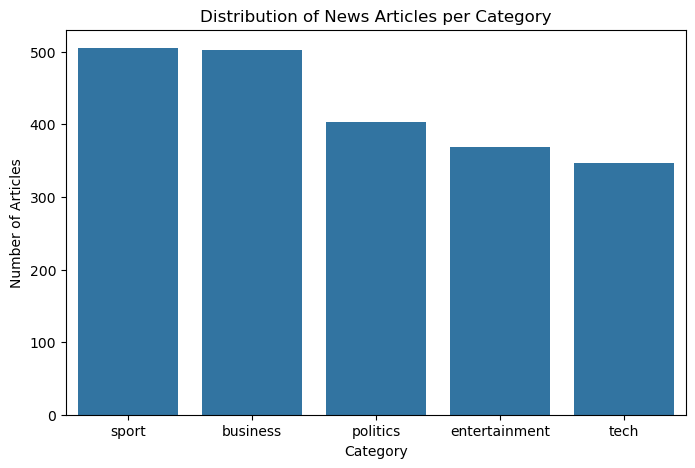

In [111]:
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Distribution of News Articles per Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.show()

In [112]:
from wordcloud import WordCloud


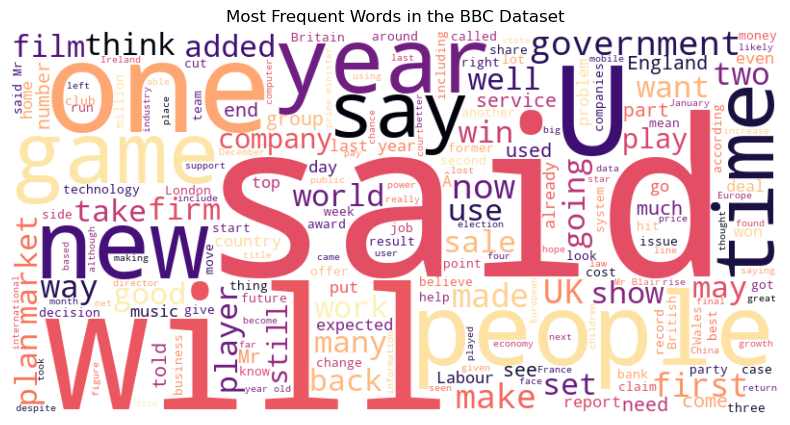

In [113]:
# Combine all text into one giant string
all_text = " ".join(text for text in df.text)

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most Frequent Words in the BBC Dataset')
plt.show()

In [114]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [115]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [116]:
# Download NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [117]:
# Initialize Stemmer and Stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove non-alphabetic characters (punctuation/numbers)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Tokenize (split by space)
    words = text.split()
    
    # 4. Remove Stopwords and Apply Porter Stemming
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # Join back to string
    return " ".join(cleaned_words)

In [118]:
df['clean_text'] = df['text'].apply(preprocess_text)
df

,category,text,clean_text
0,business,Ad sales boost Time Warner profit\n\nQuarterly...,ad sale boost time warner profit quarterli pro...
1,business,Dollar gains on Greenspan speech\n\nThe dollar...,dollar gain greenspan speech dollar hit highes...
2,business,Yukos unit buyer faces loan claim\n\nThe owner...,yuko unit buyer face loan claim owner embattl ...
3,business,High fuel prices hit BA's profits\n\nBritish A...,high fuel price hit ba profit british airway b...
4,business,Pernod takeover talk lifts Domecq\n\nShares in...,pernod takeov talk lift domecq share uk drink ...
...,...,...,...
2219,tech,New consoles promise big problems\n\nMaking ga...,new consol promis big problem make game futur ...
2220,tech,BT program to beat dialler scams\n\nBT is intr...,bt program beat dialler scam bt introduc two i...
2222,tech,Be careful how you code\n\nA new European dire...,care code new european direct could put softwa...
2223,tech,US cyber security chief resigns\n\nThe man mak...,us cyber secur chief resign man make sure us c...


In [119]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [144]:
# Initialize TF-IDF 
tfidf = TfidfVectorizer(max_features=5000, min_df = 3)

# Transform text to numbers
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['category']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
X_train.shape

(1701, 5000)

In [146]:
X_test.shape

(426, 5000)

In [147]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [148]:
# Train Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [149]:
# Predict
y_pred_nb = nb_model.predict(X_test)

In [150]:
# Evaluate
nb_acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")
print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9671

Classification Report (Naive Bayes):

               precision    recall  f1-score   support

     business       0.97      0.98      0.98       104
entertainment       0.99      0.88      0.93        78
     politics       0.91      1.00      0.95        73
        sport       1.00      1.00      1.00        98
         tech       0.96      0.96      0.96        73

     accuracy                           0.97       426
    macro avg       0.97      0.96      0.96       426
 weighted avg       0.97      0.97      0.97       426



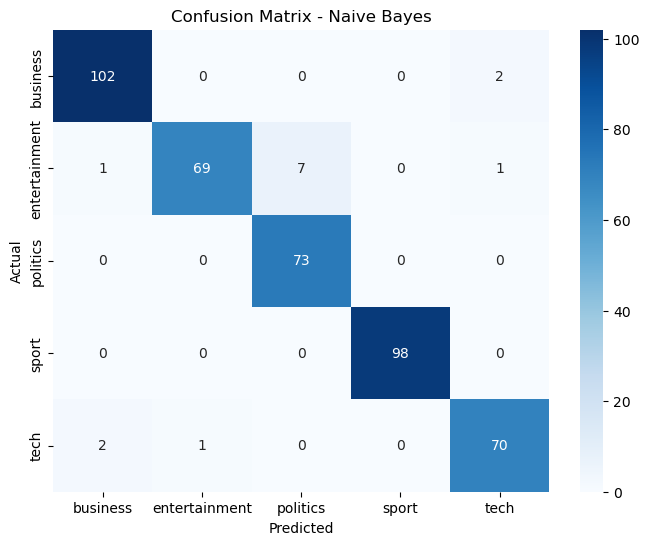

In [151]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [152]:
from sklearn.svm import LinearSVC


In [153]:
# Train Model 
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [154]:
# Predict
y_pred_svm = svm_model.predict(X_test)

In [155]:
# Evaluate
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_acc:.4f}")
print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9789

Classification Report (SVM):

               precision    recall  f1-score   support

     business       0.97      0.96      0.97       104
entertainment       0.97      0.96      0.97        78
     politics       0.99      0.99      0.99        73
        sport       1.00      1.00      1.00        98
         tech       0.96      0.99      0.97        73

     accuracy                           0.98       426
    macro avg       0.98      0.98      0.98       426
 weighted avg       0.98      0.98      0.98       426



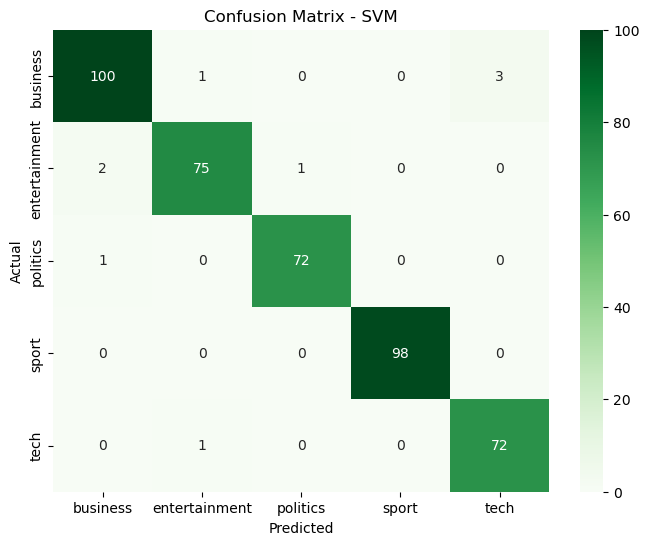

In [156]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens', 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

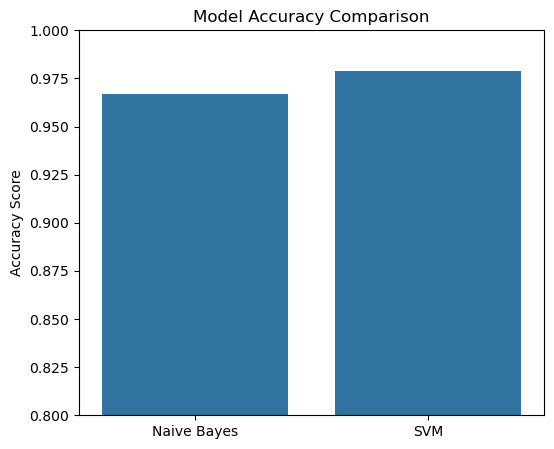

--- Prediction Test ---
Input Text: The stock market crashed today after the tech giant announced huge losses.
Naive Bayes Prediction: business
SVM Prediction: business


In [157]:
# Compare Accuracies
models = ['Naive Bayes', 'SVM']
accuracies = [nb_acc, svm_acc]

plt.figure(figsize=(6, 5))
sns.barplot(x=models, y=accuracies)
plt.ylim(0.8, 1.0) # Zoom in to see difference
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.show()

sample_text = ["The stock market crashed today after the tech giant announced huge losses."]
sample_vec = tfidf.transform([preprocess_text(sample_text[0])])

pred_nb = nb_model.predict(sample_vec)[0]
pred_svm = svm_model.predict(sample_vec)[0]

print("--- Prediction Test ---")
print(f"Input Text: {sample_text[0]}")
print(f"Naive Bayes Prediction: {pred_nb}")
print(f"SVM Prediction: {pred_svm}")

In [158]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Binarize the labels (Convert 'Sport' into [0,0,0,1,0] for plotting)
classes = svm_model.classes_
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

# 2. Get the "Scores" from both models
# Naive Bayes uses probabilities (0.0 to 1.0)
y_score_nb = nb_model.predict_proba(X_test)

# SVM uses decision function (distance from the margin)
y_score_svm = svm_model.decision_function(X_test)

print("Data prepared for plotting.")

Data prepared for plotting.


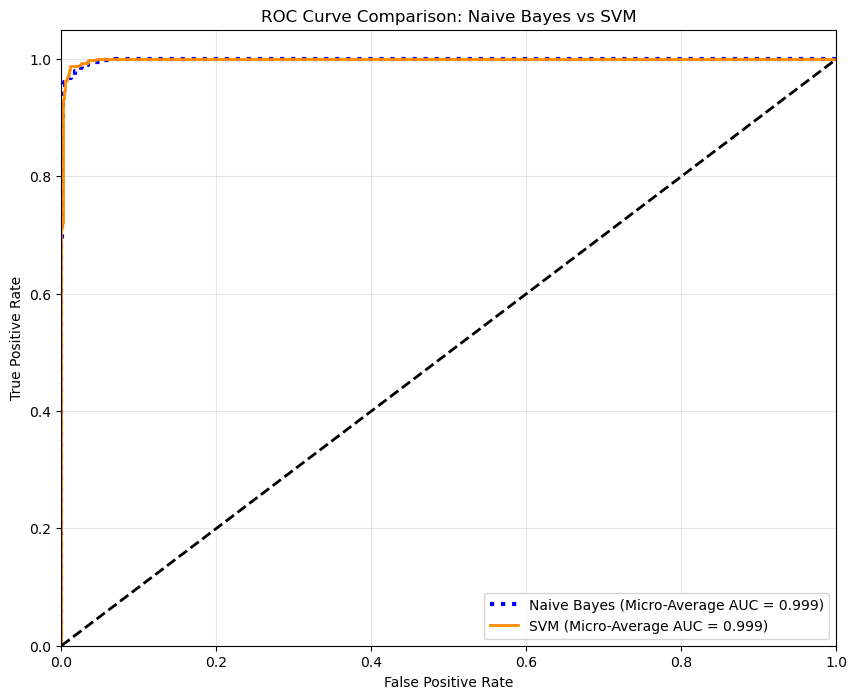

In [159]:
# Compute ROC curve and ROC area for each class
fpr_nb, tpr_nb, _ = roc_curve(y_test_bin.ravel(), y_score_nb.ravel())
roc_auc_nb = auc(fpr_nb, tpr_nb)

fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_score_svm.ravel())
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plotting
plt.figure(figsize=(10, 8))

# Plot Naive Bayes
plt.plot(fpr_nb, tpr_nb,
         label=f'Naive Bayes (Micro-Average AUC = {roc_auc_nb:.3f})',
         color='blue', linestyle=':', linewidth=3)

# Plot SVM
plt.plot(fpr_svm, tpr_svm,
         label=f'SVM (Micro-Average AUC = {roc_auc_svm:.3f})',
         color='darkorange', linewidth=2)

# Plot Diagonal (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Naive Bayes vs SVM')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

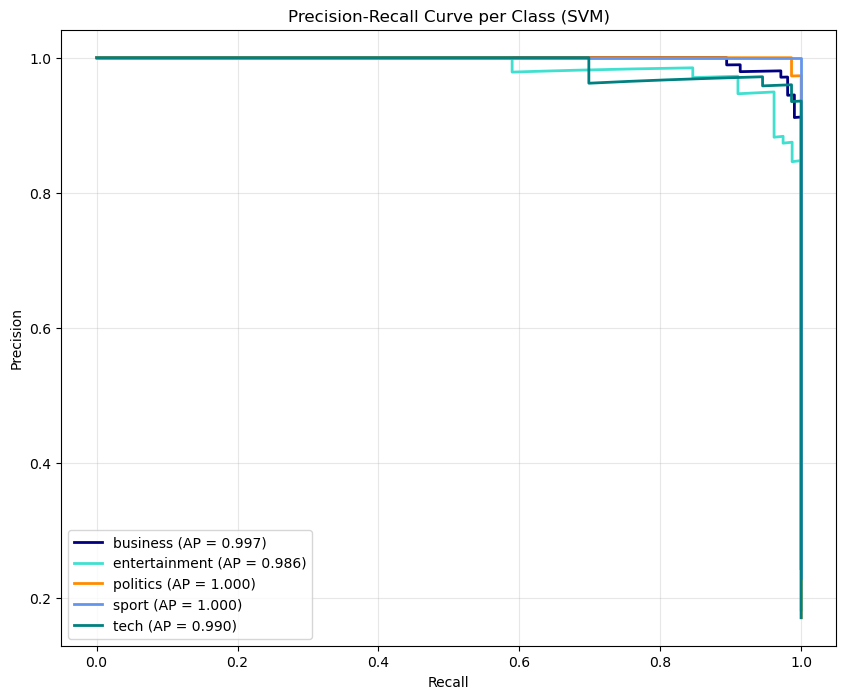

In [160]:
from itertools import cycle

# Setup plot
plt.figure(figsize=(10, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

# Plot PR Curve for each class (SVM Model)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_svm[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score_svm[:, i])
    
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{classes[i]} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class (SVM)')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

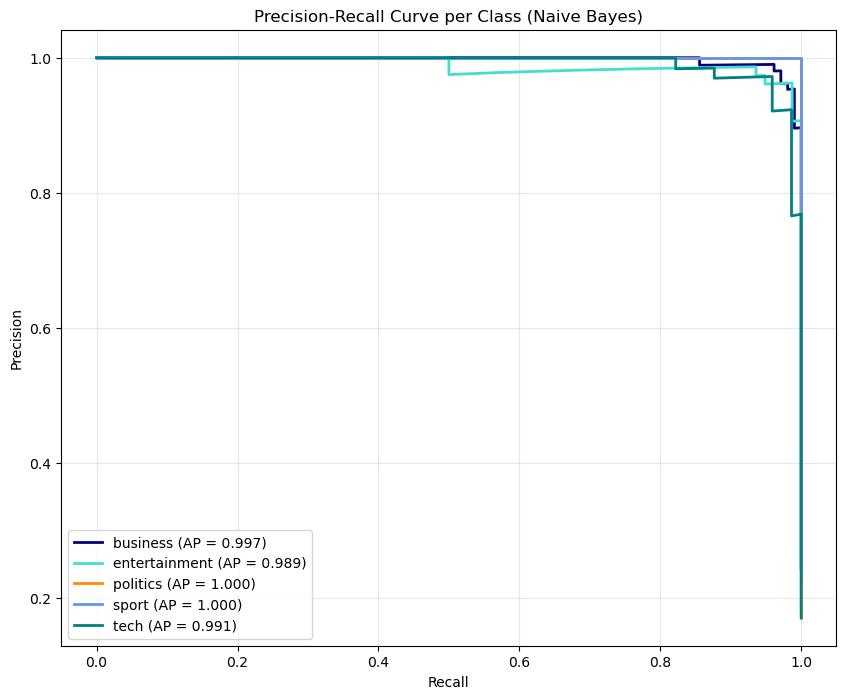

In [161]:
# Setup plot
plt.figure(figsize=(10, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

# Plot PR Curve for each class (Naive Bayes Model)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_nb[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score_nb[:, i])
    
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{classes[i]} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class (Naive Bayes)')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

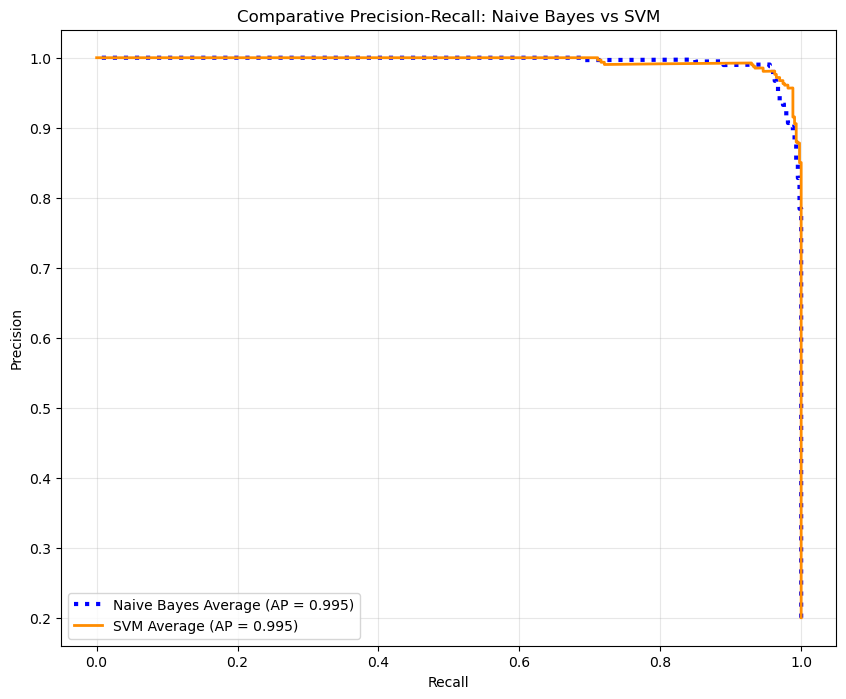

In [162]:
# Calculate Micro-Average Precision-Recall
precision_nb_micro, recall_nb_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_score_nb.ravel())
ap_nb_micro = average_precision_score(y_test_bin, y_score_nb, average="micro")

precision_svm_micro, recall_svm_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_score_svm.ravel())
ap_svm_micro = average_precision_score(y_test_bin, y_score_svm, average="micro")

# Plot Comparison
plt.figure(figsize=(10, 8))

plt.plot(recall_nb_micro, precision_nb_micro, 
         label=f'Naive Bayes Average (AP = {ap_nb_micro:.3f})',
         color='blue', linestyle=':', linewidth=3)

plt.plot(recall_svm_micro, precision_svm_micro, 
         label=f'SVM Average (AP = {ap_svm_micro:.3f})',
         color='darkorange', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparative Precision-Recall: Naive Bayes vs SVM')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()